In [ ]:
# @title
import pandas as pd #Data Analize
import numpy as np #Data Analize
import matplotlib.pyplot as plt #Data Visualization
import seaborn as sns #Data Visualization
from sklearn.model_selection import train_test_split#to split dataset into training and testing
from sklearn.linear_model import LinearRegression#import linear regression model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report#evaluation

In [ ]:
np.random.seed(42)

screentime= np.random.uniform(1,10,100)
batteryuse = 10 * screentime + np.random.normal(0,5,100)

df = pd.DataFrame({
    "screentime":screentime.round(2),
    "batteryuse":batteryuse.round(2)
})
df

,screentime,batteryuse
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


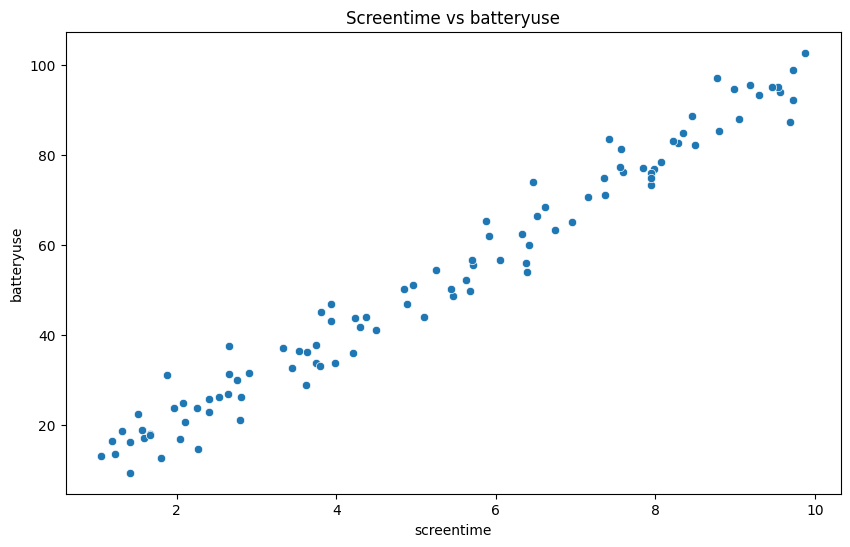

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="screentime",y="batteryuse")
plt.title("Screentime vs batteryuse")
plt.xlabel("screentime")
plt.ylabel("batteryuse")
plt.show()

Data cleaning

In [ ]:
# @title
df.head()

,screentime,batteryuse
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94


In [ ]:
# @title
df.tail()

,screentime,batteryuse
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67
99,1.97,23.85


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   screentime  100 non-null    float64
 1   batteryuse  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [ ]:
df.describe()


,screentime,batteryuse
count,100.000000,100.000000
mean,5.232100,52.311100
std,2.677397,26.477629
min,1.050000,9.470000
25%,2.735000,29.730000
50%,5.175000,49.990000
75%,7.575000,76.092500
max,9.880000,102.730000


In [ ]:
df.isnull().sum()

,0
screentime,0
batteryuse,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,screentime,batteryuse
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [ ]:
df.dropna()

,screentime,batteryuse
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [ ]:
df.dtypes

,0
screentime,float64
batteryuse,float64


In [ ]:
df.shape

(100, 2)

Train Model

In [ ]:
#define features amd target

#input / independent variable
x = df[["screentime"]]

#output / dependent variable y
y = df["batteryuse"]

#split data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#create linear regression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

Text Model

In [ ]:
y_pred = model.predict(x_test)

individual value testing

In [ ]:
y_pred = model.predict(x_test)

Evaluate model

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
#calculate Mean Absolute Error
mae = mean_absolute_error(y_test,y_pred)
mae

2.9480370450598263

In [ ]:
#calculate Mean Square Error
mse = mean_squared_error(y_test,y_pred)
mse

16.262700706811483

In [ ]:

#calculate R2 score
r2 = r2_score(y_test,y_pred)
r2

0.9784699264524137

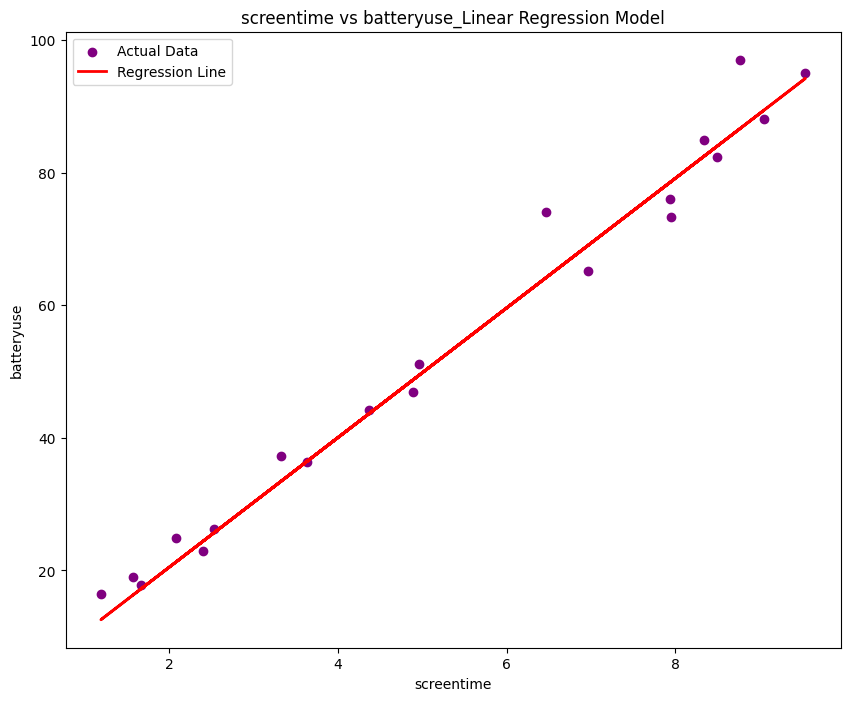

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x_test,y_test,color="purple",label="Actual Data" )
plt.plot(x_test,y_pred,color="red",linewidth=2,label="Regression Line")
plt.xlabel("screentime")
plt.ylabel("batteryuse")
plt.title("screentime vs batteryuse_Linear Regression Model")
plt.legend()
plt.show()

In [ ]:
#predict marks for new screentime
new_time = [[100.100]]
predicted_batteryuse = model.predict(new_time)
predicted_batteryuse.round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([979.53])

In [ ]:
print("slop (co-efficient):",model.coef_)

slop (co-efficient): [9.77619009]


In [ ]:
print("Intercept:",model.intercept_)

Intercept: 0.9362079717257998


In [ ]:
#display regression equation
print("\nRegression Equation:")
print(f"batteryuse = {model.coef_[0]:.2f}* screentime+ {model.intercept_:.2f}")


Regression Equation:
batteryuse = 9.78* screentime+ 0.94


In [ ]:
import joblib

#save the trained model
joblib.dump(model,"batteryuse.pkl")

#display message when saved
print("Model saved successfully")